In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, poisson


# Esercitazione 1

Probabilità p: 0.1
Valore atteso (mu): 100.0
Deviazione std (sigma): 9.49


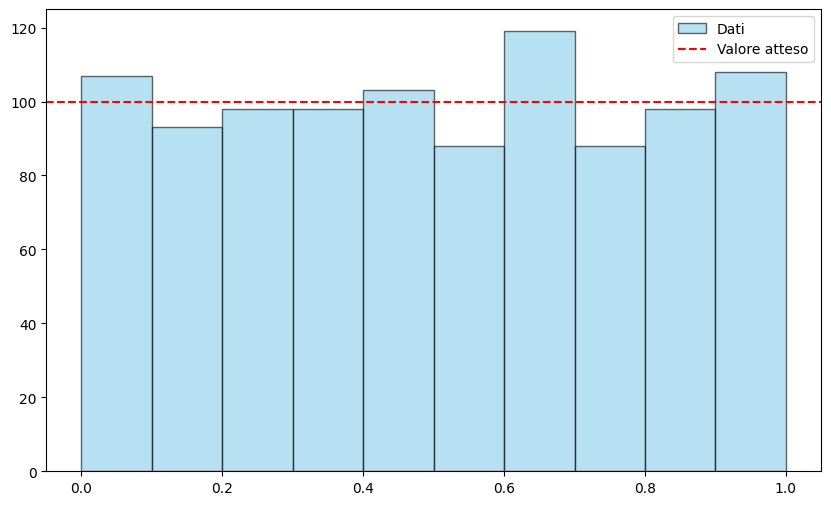

In [59]:
# Parametri iniziali
N = 1000
n_bins = 10

# Generazione dati e istogramma
dati = np.random.uniform(0, 1, N)

plt.figure(figsize=(10, 6))
# 'conteggi' riceve quanti eventi sono finiti in ogni colonna
conteggi, bordi, _ = plt.hist(dati, bins=n_bins, range=(0, 1), color='skyblue', alpha=0.6, label='Dati', edgecolor='black')

# Calcoli
p = 1 / n_bins
mu = N * p
sigma = np.sqrt(N * p * (1 - p))

print(f"Probabilità p: {p}")
print(f"Valore atteso (mu): {mu}")
print(f"Deviazione std (sigma): {sigma:.2f}")

# Linea del valore atteso
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')
plt.legend()
plt.show()

In [60]:
# Punto 2
M = 1000  # Numero ripetizioni
conteggi_bin = []

# Ciclo
for i in range(M):
    # Genero nuovi dati
    dati_temp = np.random.uniform(0, 1, N)

    # Calcolo istogramma
    conteggi, _ = np.histogram(dati_temp, bins=n_bins, range=(0, 1))

    # Prendo solo il numero di eventi caduti nel 5° bin (indice 4 perché si conta da 0)
    # E lo aggiungo alla mia lista 'conteggi_bin'
    conteggi_bin.append(conteggi[4])


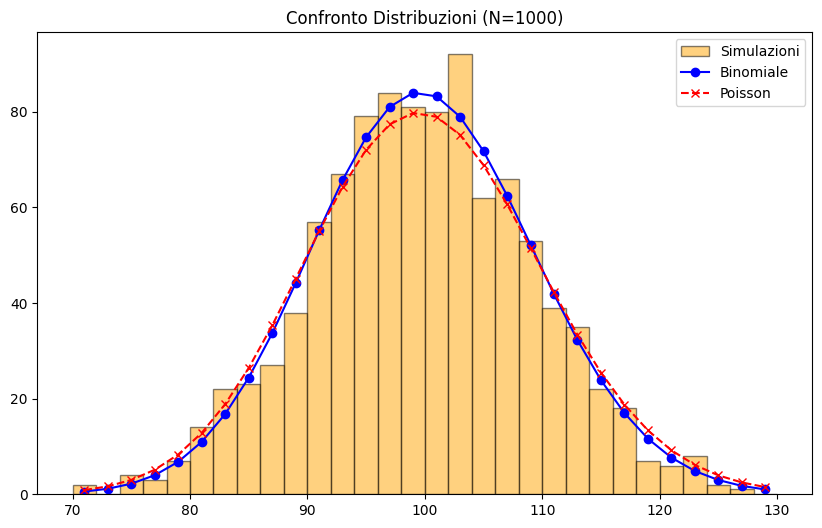

In [61]:
plt.figure(figsize=(10, 6))

# Istogramma dei risultati delle 1000 simulazioni
# Range [70, 130] e 30 bin
h, bordi, _ = plt.hist(conteggi_bin, bins=30, range=(70, 130), alpha=0.5, color='orange', edgecolor='black', label='Simulazioni')

# Calcolo centro dei bin e larghezza per le curve
centri = (bordi[:-1] + bordi[1:]) / 2
delta_x = bordi[1] - bordi[0] # Larghezza del bin (serve per scalare le curve)

# Curva Binomiale (Punto 3)
# binom.pmf calcola la probabilità teorica.
# Moltiplichiamo per M * delta_x per adattare l'altezza della curva all'istogramma dei conteggi.

y_binom = binom.pmf(np.floor(centri), N, p) * M * delta_x # floor serve a rendere intero il numero
plt.plot(centri, y_binom, 'b-o', label='Binomiale') # x; y; stile (blue; solid line; circle)

# Curva Poissoniana (Punto 4)
# La Poisson dipende solo da lambda (valore medio), che qui è N*p
lam = N * p
y_pois = poisson.pmf(np.floor(centri), lam) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.legend()
plt.title(f'Confronto Distribuzioni (N={N})')
plt.show()

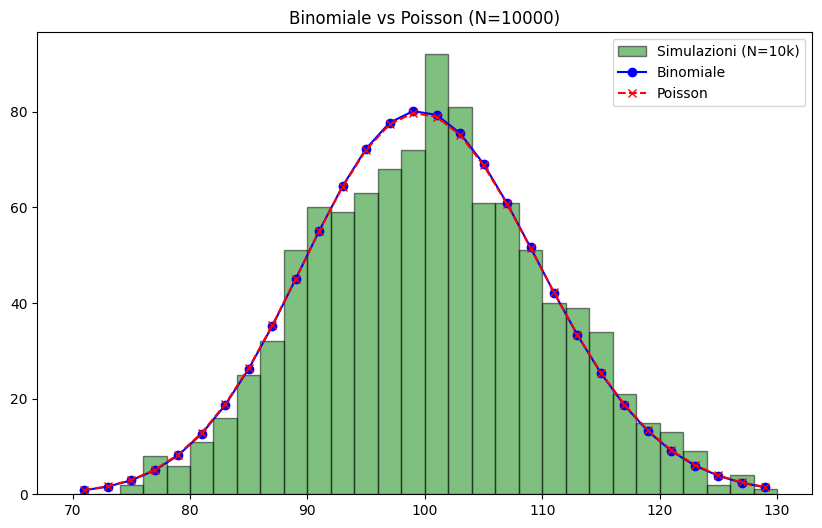

In [62]:
# Punto 5
N_2 = 10000
n_bins_2 = 100
p_2 = 1 / n_bins_2

conteggi_2 = []

# Ripeto la simulazione M volte
for i in range(M):
    dati_temporanei = np.random.uniform(0, 1, N_2)
    conteggi_temp, _ = np.histogram(dati_temporanei, bins=n_bins_2, range=(0, 1))
    conteggi_2.append(conteggi_temp[50])

# Grafico
plt.figure(figsize=(10, 6))

h, bordi, _ = plt.hist(conteggi_2, bins=30, range=(70, 130),
                       alpha=0.5, color='green', edgecolor='black', label='Simulazioni (N=10k)')

centri = (bordi[:-1] + bordi[1:]) / 2 #lati sinistri + destri / 2
delta_x = bordi[1] - bordi[0] #assumendo che abbia bin tutti equispaziati

# Binomiale
y_binom = binom.pmf(np.floor(centri), N_2, p_2) * M * delta_x
plt.plot(centri, y_binom, 'b-o', label='Binomiale')

# Poisson
lambda_2 = N_2 * p_2 # = 100
y_pois = poisson.pmf(np.floor(centri), lambda_2) * M * delta_x
plt.plot(centri, y_pois, 'r--x', label='Poisson')

plt.title('Binomiale vs Poisson (N=10000)')
plt.legend()
plt.show()

# Esercitazione 2

## Parte A

In [63]:
import numpy as np
import matplotlib.pyplot as plt

<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\45060328.py:15: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri_bin, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')


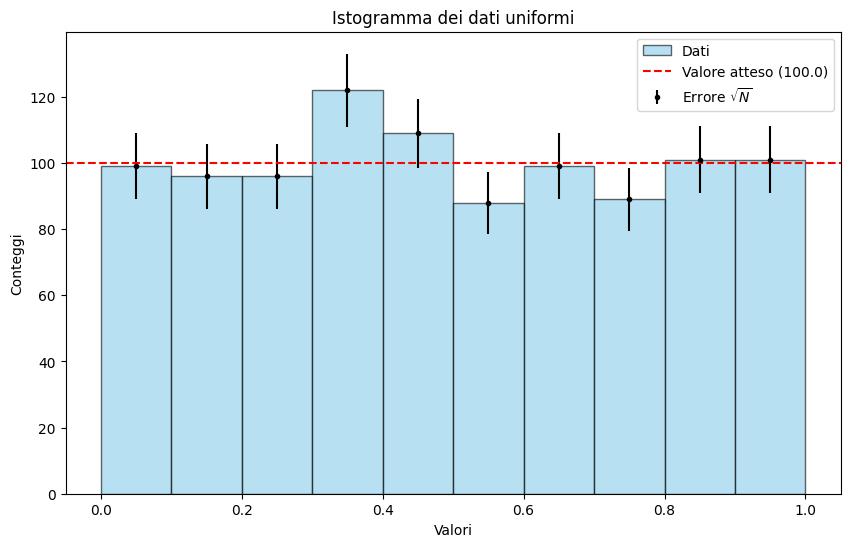

In [64]:
N = 1000
dati_uni = np.random.uniform(0, 1, N)
p = 1 / 10
mu = N * p 

plt.figure(figsize=(10, 6))
conteggi, bordi, _ = plt.hist(dati_uni, bins=10, range=(0, 1), 
                              color='skyblue', alpha=0.6, label='Dati', edgecolor='black')

# AGGIUNGO GLI ERRORI
#calcolo il centro di ogni bin per posizionare l'errore
centri_bin = (bordi[:-1] + bordi[1:]) / 2
errori = np.sqrt(conteggi)  # Radice dei conteggi

plt.errorbar(centri_bin, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')

plt.axhline(mu, color='red', linestyle='--', label=f'Valore atteso ({mu})')

plt.xlabel('Valori')
plt.ylabel('Conteggi')
plt.title('Istogramma dei dati uniformi')
plt.legend()
plt.show()

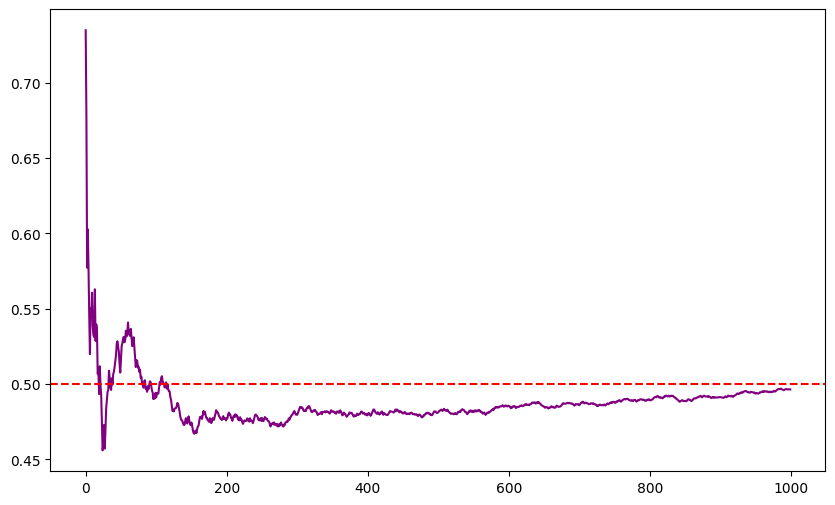

In [65]:
medie = []
mu = 0.5  

for i in range(N):
    miao = np.mean(dati_uni[:i+1])
    medie.append(miao)


plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='purple', label='Medie')
plt.axhline(mu, color='red', linestyle='--', label='Valore atteso')

<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\4282305167.py:18: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')


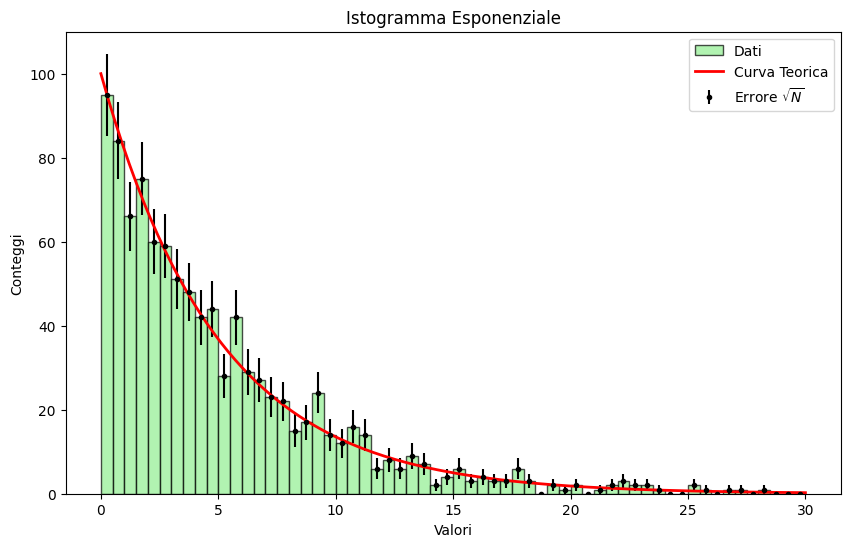

In [66]:

N = 1000
tau = 5
dati_uni = np.random.uniform(0, 1, N)
data_exp = -tau * np.log(1 - dati_uni)

n_bins = 60
raggio = (0, 30)
delta_x = (raggio[1] - raggio[0]) / n_bins # cioè 0.5

plt.figure(figsize=(10, 6))


conteggi, bordi, _ = plt.hist(data_exp, bins=n_bins, range=raggio, color='lightgreen', edgecolor='black', alpha=0.7, label='Dati')

# 4. AGGIUNGO ERRORI 
centri = (bordi[:-1] + bordi[1:]) / 2
errori = np.sqrt(conteggi)
plt.errorbar(centri, conteggi, yerr=errori, fmt='.', color='black', label='Errore $\sqrt{N}$')

#  LINEA TEORICA 
x = np.linspace(0, 30, 200) # Le X sono necessarie per allineare il grafico
y = N * delta_x * (1/tau * np.exp(-x/tau)) 

plt.plot(x, y, color='red', lw=2, label='Curva Teorica') # lw è lo spessore della linea

plt.xlabel('Valori')
plt.ylabel('Conteggi')
plt.title('Istogramma Esponenziale')
plt.legend()
plt.show()

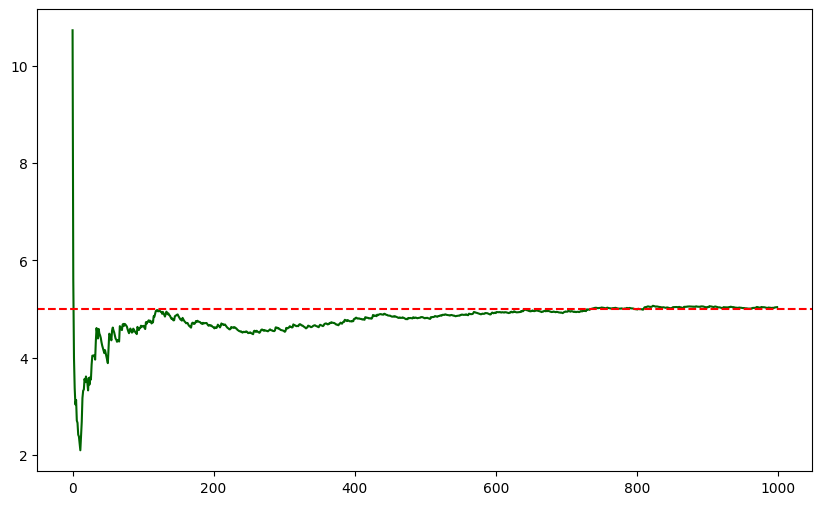

In [67]:
medie = []

for i in range(N):
    # Prendi i dati esponenziali dall'inizio fino all'indice i+1
    fetta_di_dati = data_exp[:i+1]
    
    # Calcola la media di questa fetta
    miao = np.mean(fetta_di_dati)
    
    medie.append(miao)


plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='darkgreen', label='Medie')
plt.axhline(tau, color='red', linestyle='--', label='Valore atteso')

<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\3225012893.py:12: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black', label='Errore $\sqrt{N}$')


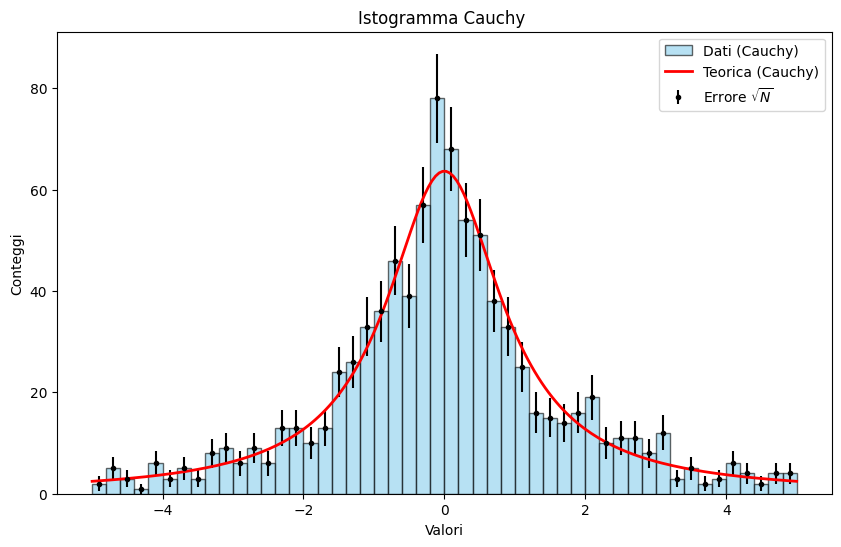

In [68]:
data_cauchy = np.random.randn(N) / np.random.randn(N)

plt.figure(figsize=(10, 6))
bin_range = (-5, 5)
bins_n = 50
delta_x = (bin_range[1] - bin_range[0]) / bins_n

conteggi, bordi, _ = plt.hist(data_cauchy, bins=bins_n, range=bin_range, 
                              color='skyblue', alpha=0.6, label='Dati (Cauchy)', edgecolor='black')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black', label='Errore $\sqrt{N}$')

x = np.linspace(-5, 5, 200)
# Formula della PDF di Cauchy: 1 / (pi * (1 + x^2))
pdf_cauchy = 1 / (np.pi * (1 + x**2))
y_teorica = N * delta_x * pdf_cauchy

plt.plot(x, y_teorica, 'r-', lw=2, label='Teorica (Cauchy)')

plt.title("Istogramma Cauchy ")
plt.xlabel("Valori")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

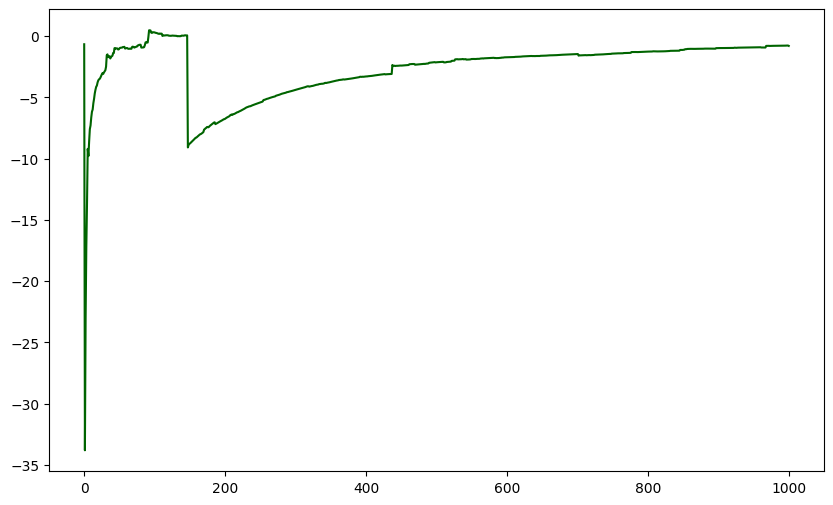

In [69]:
# Generazione dati Cauchy (rapporto di due normali)
medie = []

for i in range(N):
    # Prendi i dati esponenziali dall'inizio fino all'indice i+1
    fetta_di_dati = data_cauchy[:i+1]
    
    # Calcola la media di questa fetta
    miao = np.mean(fetta_di_dati)
    
    medie.append(miao)



plt.figure(figsize=(10, 6)) 
plt.plot(medie, color='darkgreen', label='Medie')


## Parte B

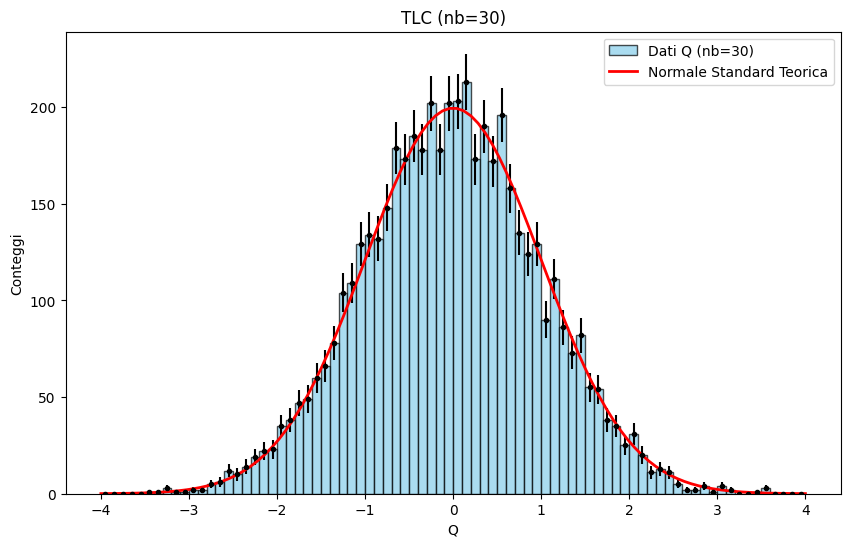

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

m = 5000
nb = 30  #  con 5, 30, 100
mu = 0.5
sigma = np.sqrt(1/12)

# Generiamo 5000 medie campionarie
medie_campionarie = []
for i in range(m):
    campione = np.random.uniform(0, 1, nb)
    medie_campionarie.append(np.mean(campione))

# 5. Calcoliamo la quantità Q
medie_campionarie = np.array(medie_campionarie)
Q = (medie_campionarie - mu) / (sigma / np.sqrt(nb))

# 6. Istogramma di Q (80 bins, range -4, 4)
plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-4, 4)
delta_x = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(Q, bins=n_bins, range=raggio, color='skyblue', 
                              edgecolor='black', alpha=0.7, label=f'Dati Q (nb={nb})')

# Aggiungiamo errori (sqrt dei conteggi)
centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# 7. Sovrapponiamo la Normale Standard teorica
x = np.linspace(-4, 4, 100)
y_teorica = m * delta_x * norm.pdf(x, 0, 1) # m * ampiezza_bin * densità_normale
plt.plot(x, y_teorica, 'r-', lw=2, label='Normale Standard Teorica')

plt.title(f"TLC (nb={nb})")
plt.xlabel("Q")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

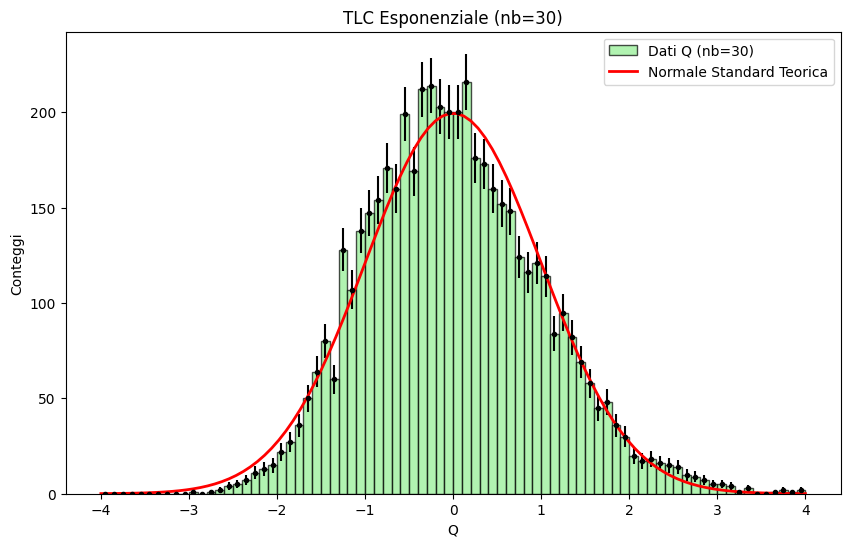

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

m = 5000
nb = 30  #  con 5, 30, 100
tau = 5
mu = tau
sigma = tau

# Generiamo le 5000 medie
medie_campionarie = []
for i in range(m):
    u = np.random.uniform(0, 1, nb)
    campione = -tau * np.log(1 - u)
    medie_campionarie.append(np.mean(campione))

medie_campionarie = np.array(medie_campionarie)
Q = (medie_campionarie - mu) / (sigma / np.sqrt(nb))

# Istogramma
plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-4, 4)
delta_x = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(Q, bins=n_bins, range=raggio, color='lightgreen', 
                              edgecolor='black', alpha=0.7, label=f'Dati Q (nb={nb})')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# Normale Standard teorica
x = np.linspace(-4, 4, 100)
y_teorica = m * delta_x * norm.pdf(x, 0, 1)
plt.plot(x, y_teorica, 'r-', lw=2, label='Normale Standard Teorica')

plt.title(f"TLC Esponenziale (nb={nb})")
plt.xlabel("Q")
plt.ylabel("Conteggi")
plt.legend()
plt.show()

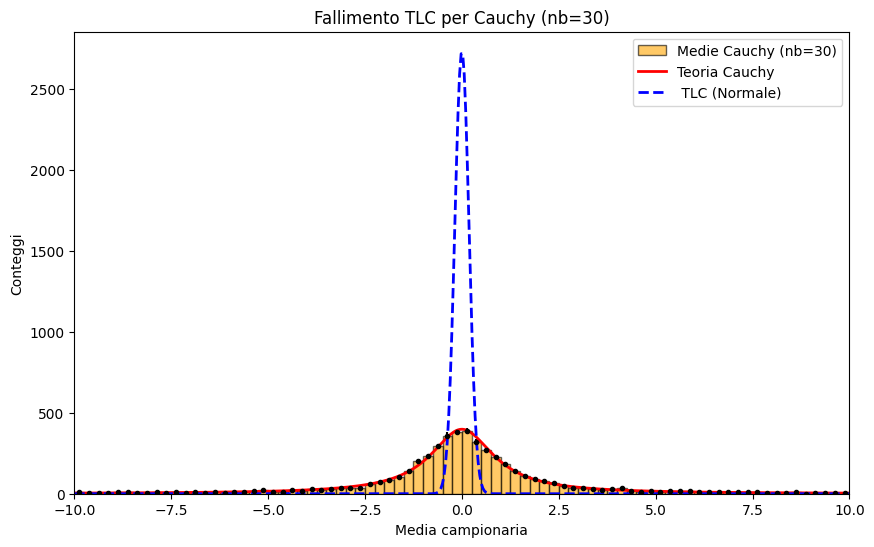

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy

m = 5000
nb = 30  #  con 5, 30, 100

# Generiamo le medie campionarie
medie_campionarie = []
for i in range(m):
    campione = np.random.randn(nb) / np.random.randn(nb) # Generazione Cauchy
    medie_campionarie.append(np.mean(campione))

medie_campionarie = np.array(medie_campionarie)

plt.figure(figsize=(10, 6))
n_bins = 80
raggio = (-10, 10)
delta_x = (raggio[1] - raggio[0]) / n_bins

conteggi, bordi, _ = plt.hist(medie_campionarie, bins=n_bins, range=raggio, color='orange', 
                              edgecolor='black', alpha=0.6, label=f'Medie Cauchy (nb={nb})')

centri = (bordi[:-1] + bordi[1:]) / 2
plt.errorbar(centri, conteggi, yerr=np.sqrt(conteggi), fmt='.', color='black')

# Curve teoriche
x = np.linspace(-10, 10, 500)

# 1. Curva di Cauchy 
y_cauchy = m * delta_x * cauchy.pdf(x)
plt.plot(x, y_cauchy, 'r-', lw=2, label='Teoria Cauchy')

# 2. Curva Normale (quella che il TLC vorrebbe ma che qui fallisce)
# Per confronto uso sigma = 1/sqrt(nb) come se fosse una distribuzione normale
y_normale = m * delta_x * norm.pdf(x, 0, 1/np.sqrt(nb))
plt.plot(x, y_normale, 'b--', lw=2, label=' TLC (Normale)')

plt.title(f"Fallimento TLC per Cauchy (nb={nb})")
plt.xlabel("Media campionaria")
plt.ylabel("Conteggi")
plt.xlim(-10, 10)
plt.legend()
plt.show()

# Esercitazione 3


<>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\117169662.py:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax1.errorbar(centri1, conteggi1, yerr=np.sqrt(conteggi1), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\117169

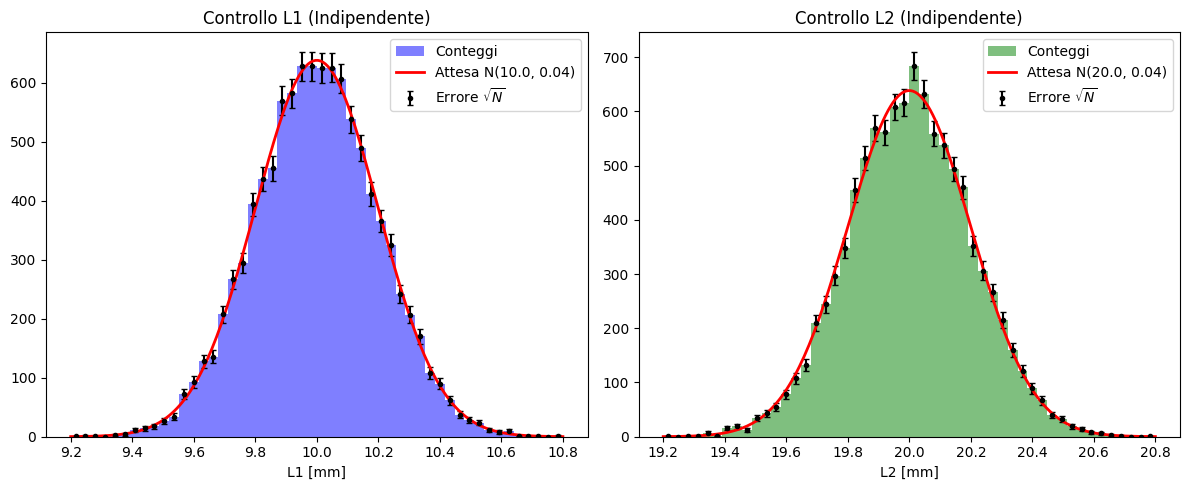

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


np.random.seed(42) # Fissiamo il seed per avere risultati riproducibili  
n = 10000
mu1, mu2 = 10.0, 20.0
sigma = 0.2

# Generazione dati indipendenti
L1 = np.random.normal(mu1, sigma, n)
L2 = np.random.normal(mu2, sigma, n)

# Impostiamo una griglia di grafici 1x2 per i controlli iniziali
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Istogramma L1 ---
conteggi1, bins1, _ = ax1.hist(L1, bins=50, range=(mu1-4*sigma, mu1+4*sigma), color='blue', alpha=0.5, label='Conteggi')
centri1 = (bins1[:-1] + bins1[1:]) / 2
ax1.errorbar(centri1, conteggi1, yerr=np.sqrt(conteggi1), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')

x1 = np.linspace(mu1-4*sigma, mu1+4*sigma, 200)
attesa1 = norm.pdf(x1, mu1, sigma) * n * (bins1[1] - bins1[0])
ax1.plot(x1, attesa1, 'r-', lw=2, label=f'Attesa N({mu1}, {sigma**2:.2f})')
ax1.set_title('Controllo L1 (Indipendente)')
ax1.set_xlabel('L1 [mm]')
ax1.legend()

# --- Istogramma L2 ---
conteggi2, bins2, _ = ax2.hist(L2, bins=50, range=(mu2-4*sigma, mu2+4*sigma), color='green', alpha=0.5, label='Conteggi')
centri2 = (bins2[:-1] + bins2[1:]) / 2
ax2.errorbar(centri2, conteggi2, yerr=np.sqrt(conteggi2), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')

x2 = np.linspace(mu2-4*sigma, mu2+4*sigma, 200)
attesa2 = norm.pdf(x2, mu2, sigma) * n * (bins2[1] - bins2[0])
ax2.plot(x2, attesa2, 'r-', lw=2, label=f'Attesa N({mu2}, {sigma**2:.2f})')
ax2.set_title('Controllo L2 (Indipendente)')
ax2.set_xlabel('L2 [mm]')
ax2.legend()

plt.tight_layout()
plt.show()

In [74]:
# 1.1 Covarianza e Correlazione manuali (con e senza Bessel)
media_L1 = np.mean(L1)
media_L2 = np.mean(L2)

# Senza correzione di Bessel (diviso n)
cov_nobessel = np.sum((L1 - media_L1) * (L2 - media_L2)) / n
var_L1_nb = np.sum((L1 - media_L1)**2) / n
var_L2_nb = np.sum((L2 - media_L2)**2) / n
corr_nobessel = cov_nobessel / np.sqrt(var_L1_nb * var_L2_nb)

# Con correzione di Bessel (diviso n-1)
cov_bessel = np.sum((L1 - media_L1) * (L2 - media_L2)) / (n - 1)
var_L1_b = np.sum((L1 - media_L1)**2) / (n - 1)
var_L2_b = np.sum((L2 - media_L2)**2) / (n - 1)
corr_bessel = cov_bessel / np.sqrt(var_L1_b * var_L2_b)

print(f"Covarianza (no Bessel): {cov_nobessel:.6f} | Correlazione: {corr_nobessel:.6f}")
print(f"Covarianza (Bessel):    {cov_bessel:.6f} | Correlazione: {corr_bessel:.6f}")
print("I valori attesi dalla teoria sono 0 (variabili indipendenti).")

Covarianza (no Bessel): -0.000344 | Correlazione: -0.008553
Covarianza (Bessel):    -0.000344 | Correlazione: -0.008553
I valori attesi dalla teoria sono 0 (variabili indipendenti).


Rapporto punti Q2 <= 1 misurato: 0.3924 (Teoria: 0.3935)


<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\274606187.py:12: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.scatter(L1[mask_q2_indep], L2[mask_q2_indep], color='red', s=2, alpha=0.8, label='Q$^2$ $\leq$ 1')


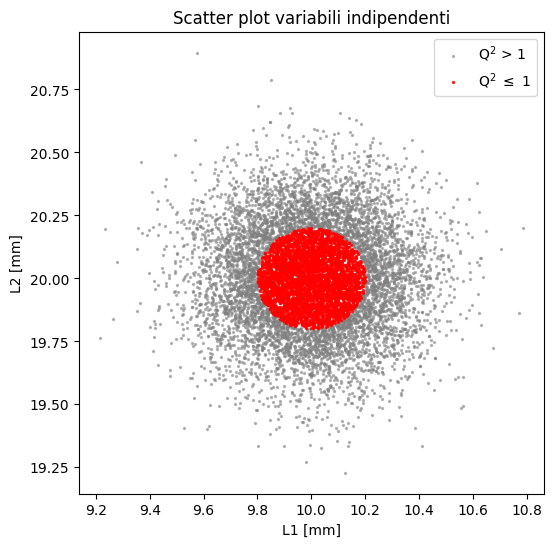

In [75]:
# 1.2 Scatter plot e Q^2
Q2_indep = ((L1 - mu1)/sigma)**2 + ((L2 - mu2)/sigma)**2
mask_q2_indep = Q2_indep <= 1

rapporto_indep = np.sum(mask_q2_indep) / n
valore_teorico = 1 - np.exp(-0.5)

print(f"Rapporto punti Q2 <= 1 misurato: {rapporto_indep:.4f} (Teoria: {valore_teorico:.4f})")

plt.figure(figsize=(6, 6))
plt.scatter(L1[~mask_q2_indep], L2[~mask_q2_indep], color='gray', s=2, alpha=0.5, label='Q$^2$ > 1')
plt.scatter(L1[mask_q2_indep], L2[mask_q2_indep], color='red', s=2, alpha=0.8, label='Q$^2$ $\leq$ 1')
plt.xlabel('L1 [mm]')
plt.ylabel('L2 [mm]')
plt.title('Scatter plot variabili indipendenti')
plt.legend()
plt.show()

<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:9: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\3500027754.py:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  conteggi_c, bins_c, _ = ax.hist(L1_cond, bins=30, color='purple', alpha=0.5, label='Conteggi (L2 $\sim$ 19.7)')
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\3500

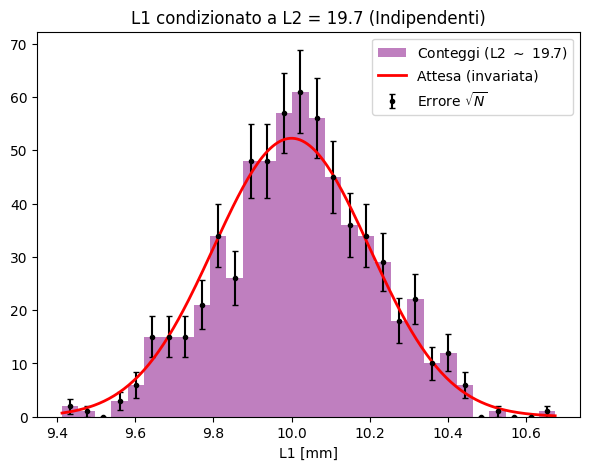

In [76]:
# 1.3 Distribuzione Condizionata
L2_r = 19.7
tol = 0.05
L1_cond = L1[(L2 >= L2_r - tol) & (L2 <= L2_r + tol)]

fig, ax = plt.subplots(figsize=(7, 5))
conteggi_c, bins_c, _ = ax.hist(L1_cond, bins=30, color='purple', alpha=0.5, label='Conteggi (L2 $\sim$ 19.7)')
centri_c = (bins_c[:-1] + bins_c[1:]) / 2
ax.errorbar(centri_c, conteggi_c, yerr=np.sqrt(conteggi_c), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')

# L'attesa per L1 non cambia se L1 e L2 sono indipendenti
x_c = np.linspace(bins_c[0], bins_c[-1], 200)
attesa_c = norm.pdf(x_c, mu1, sigma) * len(L1_cond) * (bins_c[1] - bins_c[0])
ax.plot(x_c, attesa_c, 'r-', lw=2, label='Attesa (invariata)')

ax.set_title('L1 condizionato a L2 = 19.7 (Indipendenti)')
ax.set_xlabel('L1 [mm]')
ax.legend()
plt.show()

Varianza misurata L1s: 0.1319 | Teoria: 0.1300


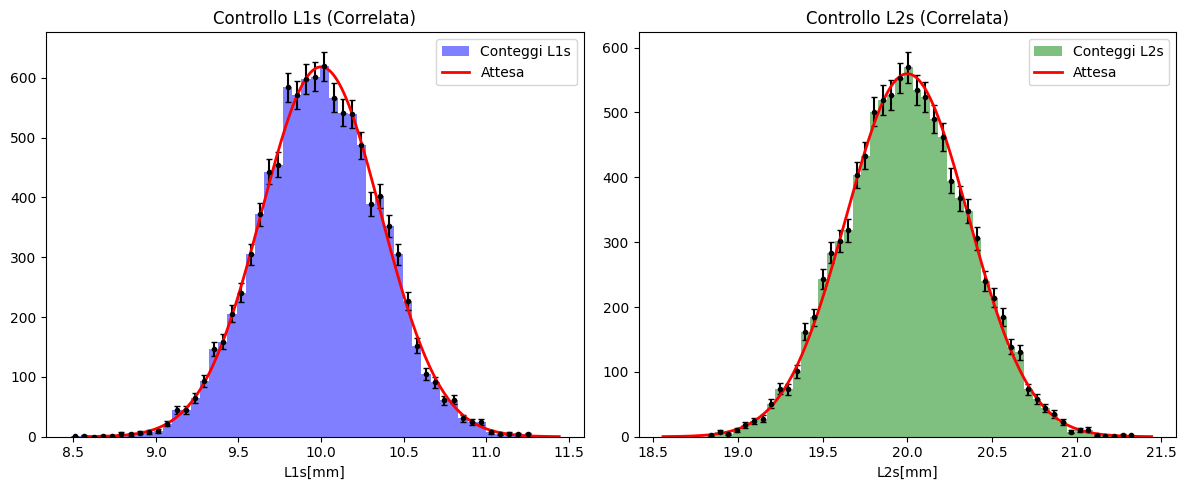

In [77]:
# Generazione errore sistematico
sigma_S = 0.3
S = np.random.normal(0, sigma_S, n)

L1s = L1 + S
L2s = L2 + S

# Varianza teorica attesa (somma delle varianze di L e S)
var_attesa_s = sigma**2 + sigma_S**2
sigma_attesa_s = np.sqrt(var_attesa_s)

# Controllo varianze empiriche (ddof=1 equivale alla correzione di Bessel)
var_mis_L1s = np.var(L1s, ddof=1)
var_mis_L2s = np.var(L2s, ddof=1)

print(f"Varianza misurata L1s: {var_mis_L1s:.4f} | Teoria: {var_attesa_s:.4f}")

# Istogrammi di controllo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- L1s ---
cnt1, b1, _ = ax1.hist(L1s, bins=50, color='blue', alpha=0.5, label='Conteggi L1s')
ax1.errorbar((b1[:-1]+b1[1:])/2, cnt1, yerr=np.sqrt(cnt1), fmt='k.', capsize=2)
x1s = np.linspace(mu1-4*sigma_attesa_s, mu1+4*sigma_attesa_s, 200)
ax1.plot(x1s, norm.pdf(x1s, mu1, sigma_attesa_s)*n*(b1[1]-b1[0]), 'r-', lw=2, label='Attesa')
ax1.set_title('Controllo L1s (Correlata)'); ax1.set_xlabel('L1s[mm]'); ax1.legend()

# --- L2s ---
cnt2, b2, _ = ax2.hist(L2s, bins=50, color='green', alpha=0.5, label='Conteggi L2s')
ax2.errorbar((b2[:-1]+b2[1:])/2, cnt2, yerr=np.sqrt(cnt2), fmt='k.', capsize=2)
x2s = np.linspace(mu2-4*sigma_attesa_s, mu2+4*sigma_attesa_s, 200)
ax2.plot(x2s, norm.pdf(x2s, mu2, sigma_attesa_s)*n*(b2[1]-b2[0]), 'r-', lw=2, label='Attesa')
ax2.set_title('Controllo L2s (Correlata)'); ax2.set_xlabel('L2s[mm]'); ax2.legend()

plt.tight_layout()
plt.show()

In [78]:
# 2.1 Covarianza e correlazione
media_L1s = np.mean(L1s)
media_L2s = np.mean(L2s)

# Uso n-1 per la covarianza (Bessel) come richiesto
cov_s = np.sum((L1s - media_L1s) * (L2s - media_L2s)) / (n - 1)
corr_s = cov_s / np.sqrt(var_mis_L1s * var_mis_L2s)

print(f"Covarianza misurata:         {cov_s:.5f}")
print(f"Covarianza teorica (var(S)): {sigma_S**2:.5f}")
print(f"Correlazione misurata (rho): {corr_s:.5f}")

Covarianza misurata:         0.09131
Covarianza teorica (var(S)): 0.09000
Correlazione misurata (rho): 0.69262


Rapporto punti Q2 <= 1 misurato: 0.3885 (Teoria: 0.3935)


<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\601594380.py:18: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  plt.scatter(L1s[mask_q2_corr], L2s[mask_q2_corr], color='red', s=2, alpha=0.8, label='Q$^2$ $\leq$ 1')


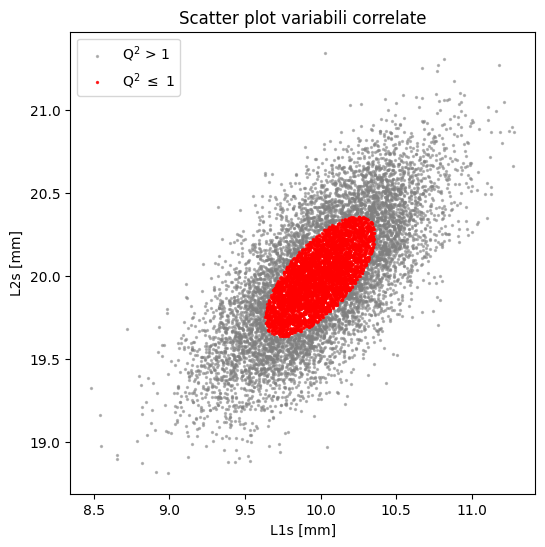

In [79]:
# 2.2 Q^2 per variabili correlate
sx = np.sqrt(var_mis_L1s)
sy = np.sqrt(var_mis_L2s)
rho = corr_s

termine_x = (L1s - media_L1s) / sx
termine_y = (L2s - media_L2s) / sy

# Formula generale del Q^2 con correlazione
Q2_corr = (1 / (1 - rho**2)) * (termine_x**2 + termine_y**2 - 2*rho*termine_x*termine_y)
mask_q2_corr = Q2_corr <= 1

rapporto_corr = np.sum(mask_q2_corr) / n
print(f"Rapporto punti Q2 <= 1 misurato: {rapporto_corr:.4f} (Teoria: {valore_teorico:.4f})")

plt.figure(figsize=(6, 6))
plt.scatter(L1s[~mask_q2_corr], L2s[~mask_q2_corr], color='gray', s=2, alpha=0.5, label='Q$^2$ > 1')
plt.scatter(L1s[mask_q2_corr], L2s[mask_q2_corr], color='red', s=2, alpha=0.8, label='Q$^2$ $\leq$ 1')
plt.xlabel('L1s [mm]')
plt.ylabel('L2s [mm]')
plt.title('Scatter plot variabili correlate')
plt.legend()
plt.show()

<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:17: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\standard\AppData\Local\Temp\ipykernel_18340\4118718451.py:10: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  ax.errorbar((b_c[:-1] + b_c[1:]) / 2, cnt_c, yerr=np.sqrt(cnt_c), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')
C:\Users\standard\AppData\Local\Temp\ipykernel_183

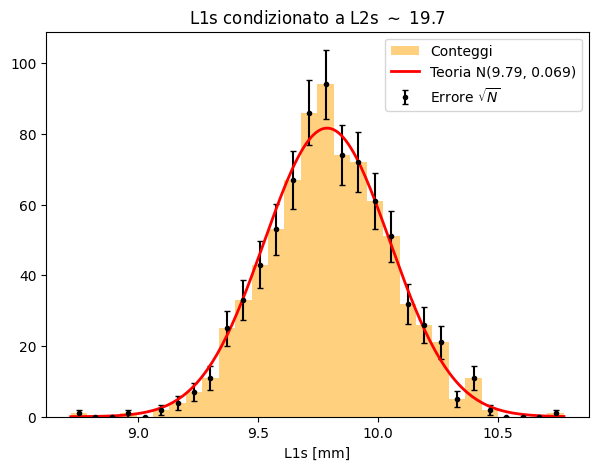

Valore atteso mu_(x|y): 9.789 mm
Larghezza attesa sigma_(x|y): 0.262 mm


In [80]:
# 2.3 Distribuzione Condizionata (variabili correlate)
L1s_cond = L1s[(L2s >= L2_r - tol) & (L2s <= L2_r + tol)]

# Parametri teorici della distribuzione condizionata (dal formulario)
mu_cond_teo = media_L1s + rho * (sx / sy) * (L2_r - media_L2s)
sigma_cond_teo = sx * np.sqrt(1 - rho**2)

fig, ax = plt.subplots(figsize=(7, 5))
cnt_c, b_c, _ = ax.hist(L1s_cond, bins=30, color='orange', alpha=0.5, label='Conteggi')
ax.errorbar((b_c[:-1] + b_c[1:]) / 2, cnt_c, yerr=np.sqrt(cnt_c), fmt='k.', capsize=2, label='Errore $\sqrt{N}$')

# Curva condizionata attesa
xc = np.linspace(b_c[0], b_c[-1], 200)
attesa_cond = norm.pdf(xc, mu_cond_teo, sigma_cond_teo) * len(L1s_cond) * (b_c[1] - b_c[0])

ax.plot(xc, attesa_cond, 'r-', lw=2, label=f'Teoria N({mu_cond_teo:.2f}, {sigma_cond_teo**2:.3f})')
ax.set_title(f'L1s condizionato a L2s $\sim$ {L2_r}')
ax.set_xlabel('L1s [mm]')
ax.legend()
plt.show()

print(f"Valore atteso mu_(x|y): {mu_cond_teo:.3f} mm")
print(f"Larghezza attesa sigma_(x|y): {sigma_cond_teo:.3f} mm")

# Esercitazione 4

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import loggamma

plt.rcParams['figure.figsize'] = (10, 6)

Maximum Likelihood
Valore stimato: tau = 4.4441 ± 0.0475 s


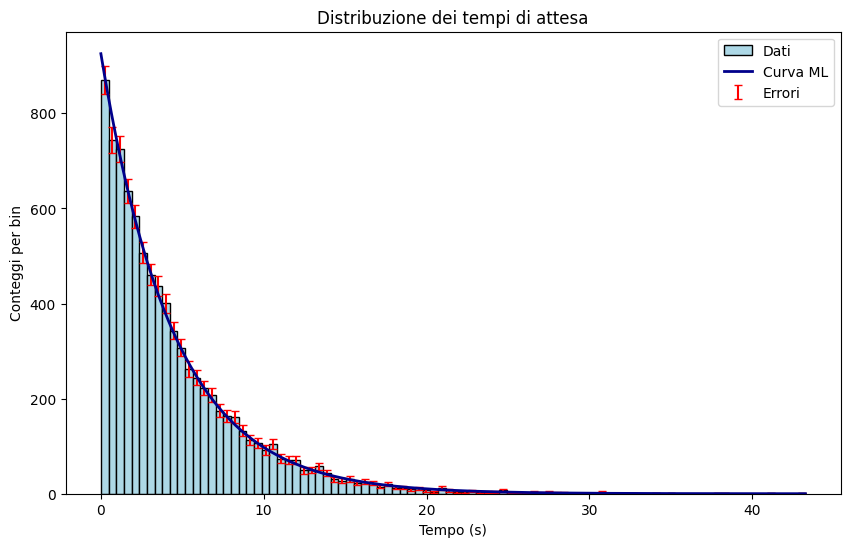

In [82]:

file = "dati/gruppo3.txt" 
dati = np.loadtxt(file) / 1000.0 # Conversione da ms a s

N = len(dati)

# Maximum Likelihood 
stima_tau = np.mean(dati)
var_tau = (stima_tau**2) / N
sigma_tau = np.sqrt(var_tau)

print("Maximum Likelihood")
print(f"Valore stimato: tau = {stima_tau:.4f} \u00B1 {sigma_tau:.4f} s")

# istogramma
n, bins, _ = plt.hist(dati, bins='auto', color='lightblue', edgecolor='black', label='Dati')
delta_x = bins[1] - bins[0]
centri = 0.5 * (bins[1:] + bins[:-1])

#barre di errore 
plt.errorbar(centri, n, yerr=np.sqrt(n), fmt='none', color='red', capsize=3, label='Errori')

#curva 
t_plot = np.linspace(0, np.max(dati), 200)
pdf_exp = np.exp(-t_plot / stima_tau) / stima_tau
plt.plot(t_plot, pdf_exp * (N * delta_x), color='darkblue', lw=2, label='Curva ML')

plt.title("Distribuzione dei tempi di attesa")
plt.xlabel("Tempo (s)")
plt.ylabel("Conteggi per bin")
plt.legend()
plt.show()

Maximum Likelihood Grafico
Valore stimato: tau = 4.4443 ± 0.0475 s



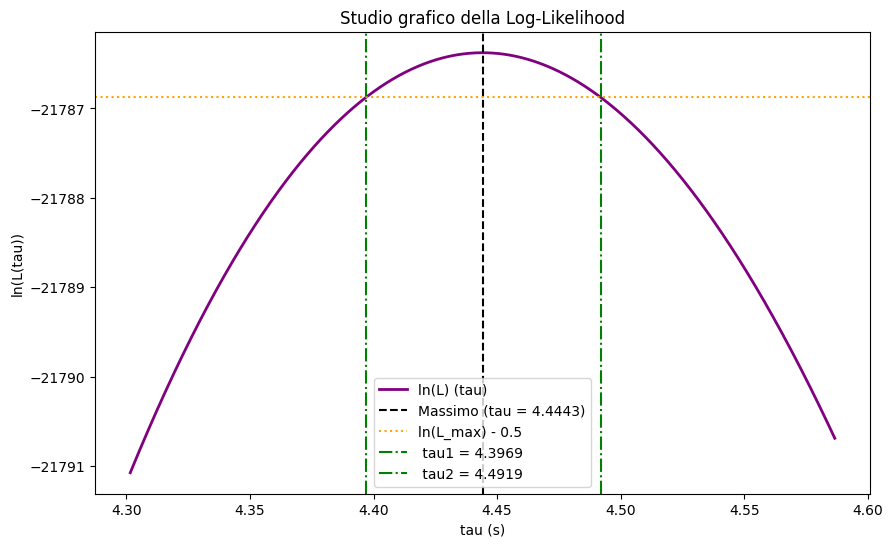

In [85]:
#vettore x di tau
tau_vals = np.linspace(stima_tau - 3*sigma_tau, stima_tau + 3*sigma_tau, 1000)
sum_t = np.sum(dati)

#calcolo logarimo della likelihood
lnL = -N * np.log(tau_vals) - sum_t / tau_vals


#calcolo numerico del massimo 
lnL_max = -np.inf # metto -inf per essere sicuro che qualsiasi valore di lnL sarà maggiore
tau_g = 0
for i in range(len(tau_vals)):  #cerco il massimo scorrendo tutti i valori di tau
    if lnL[i] > lnL_max:
        lnL_max = lnL[i]
        tau_g = tau_vals[i] # salvo il max e il tau (punto di ascissa) in cui si verifica



#ricerca tau1 e tau2
target = lnL_max - 0.5 # trovo lnL che è 0.5 unità sotto il max, che corrisponde a 1 sigma di incertezza 
tau1, tau2 = 0, 0
min_diff1, min_diff2 = np.inf, np.inf # metto le differenze minime a infinito cosi ogni differenza è minore

for i in range(len(tau_vals)): # scorro tutti i tau e confronto lnL con il target
    diff = abs(lnL[i] - target)
    if tau_vals[i] < tau_g:   # ramo sinistro
        if diff < min_diff1:
            min_diff1 = diff
            tau1 = tau_vals[i]
    else:                     # ramo destro
        if diff < min_diff2:
            min_diff2 = diff
            tau2 = tau_vals[i]

sigma_g = (tau2 - tau1) / 2 # l'incertezza è metà della distanza tra tau1 e tau2

print("Maximum Likelihood Grafico")
print(f"Valore stimato: tau = {tau_g:.4f} \u00B1 {sigma_g:.4f} s\n")

# grafico
plt.plot(tau_vals, lnL, color='purple', lw=2, label='ln(L) (tau)')
plt.axvline(x=tau_g, color='black', linestyle='--', label=f'Massimo (tau = {tau_g:.4f})')
plt.axhline(y=target, color='orange', linestyle=':', label='ln(L_max) - 0.5')
plt.axvline(x=tau1, color='green', linestyle='-.', label=f' tau1 = {tau1:.4f}')
plt.axvline(x=tau2, color='green', linestyle='-.', label=f' tau2 = {tau2:.4f}')

plt.title("Studio grafico della Log-Likelihood")
plt.xlabel("tau (s)")
plt.ylabel("ln(L(tau))")
plt.legend()
plt.show()

Simulazione Monte Carlo
Valore stimato: tau = 4.4436 ± 0.0471 s


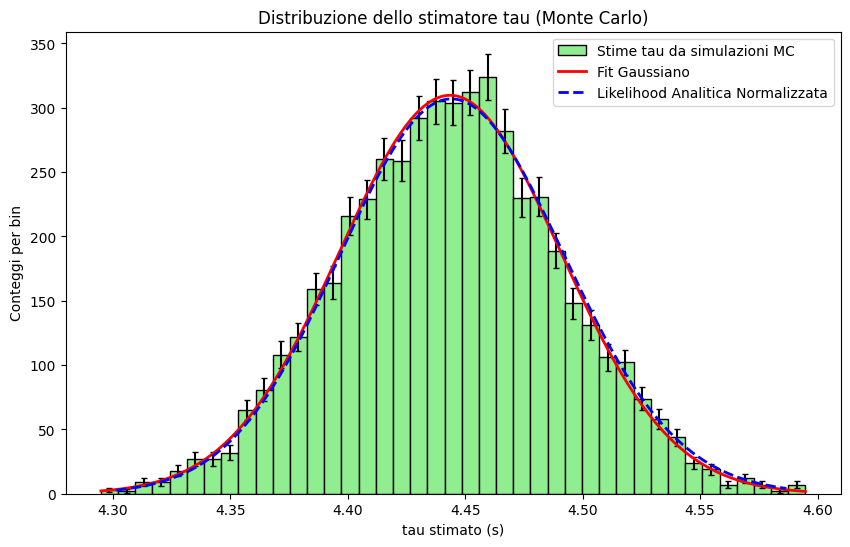

In [84]:
m = 5000
tau_simulati = np.zeros(m)

#m esperimenti 
for j in range(m):
    esperimento_mc = np.random.exponential(scale=stima_tau, size=N)
    tau_simulati[j] = np.mean(esperimento_mc)

tau_mc = np.mean(tau_simulati)
sigma_mc = np.std(tau_simulati, ddof=1) # ddof=1 per avere la stima corretta della deviazione standard campionaria (Bessel)

print("Simulazione Monte Carlo")
print(f"Valore stimato: tau = {tau_mc:.4f} \u00B1 {sigma_mc:.4f} s")

#istogramma
conteggi, bordi, _ = plt.hist(tau_simulati, bins='auto', color='lightgreen', edgecolor='black', label='Stime tau da simulazioni MC')
delta_x_mc = bordi[1] - bordi[0]
centri_mc = 0.5 * (bordi[1:] + bordi[:-1])

#errore
plt.errorbar(centri_mc, conteggi, yerr=np.sqrt(conteggi), fmt='none', ecolor='black', capsize=2)

# Sovrapposizione Gaussiana
tau_plot_mc = np.linspace(np.min(tau_simulati), np.max(tau_simulati), 200)
gauss_pdf = (1 / (sigma_mc * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((tau_plot_mc - tau_mc) / sigma_mc)**2)
plt.plot(tau_plot_mc, gauss_pdf * (m * delta_x_mc), color='red', lw=2, label='Fit Gaussiano')


# Calcolo della normalizzazione con la formula esatta dell'esercitazione
lnNorm = loggamma(N - 1) - (N - 1) * np.log(sum_t)

# Densità di probabilità normalizzata dalla Likelihood
likelihood_pdf = np.exp(lnL - lnNorm) 

# Moltiplichiamo per (totale eventi * larghezza_bin) per sovrapporre correttamente ai conteggi dell'istogramma
plt.plot(tau_vals, likelihood_pdf * (m * delta_x_mc), color='blue', linestyle='--', lw=2, label='Likelihood Analitica Normalizzata')

plt.title("Distribuzione dello stimatore tau (Monte Carlo)")
plt.xlabel("tau stimato (s)")
plt.ylabel("Conteggi per bin")
plt.legend()
plt.show()